# House Prices - Prediction Project

Projeto de Machine Learning para predição de preços de imóveis utilizando o dataset do Kaggle (*House Prices - Advanced Regression Techniques*).

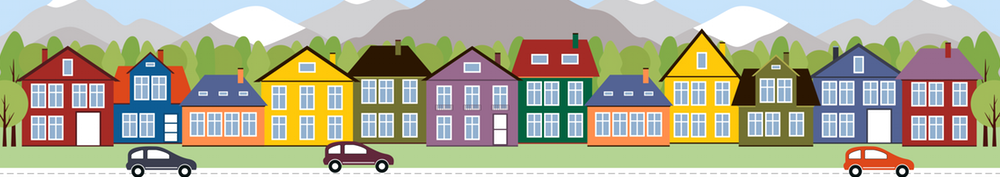

   ```text
house-prices/
├── data/
│   ├── raw/
│   │   ├── train.csv
│   │   ├── test.csv
│   │   ├── data_description.txt
│   │   └── sample_submission.csv
│   └── processed/   <--- Onde salvaremos os dados limpos e prontos

## Importando a base já Tratada e a base de Test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando a base de treino processada (ex: com log puro ou a que escolher)
train_df = pd.read_csv('../data/processed/train_if.csv')  
test_df = pd.read_csv('../data/raw/test.csv') 

print(f"Dimensões do dataset de treino processado: {train_df.shape}")
print(f"Dimensões do dataset de teste: {test_df.shape}")

## Fazer a remoção no tratamento que usamos somente Log NÃO FUNCIONA COMO ESPERADO

# Remover explicitamente os conhecidos "outliers de erro" documentados em Ames
# (Casas com GrLivArea > 4000 que são transações atípicas / parciais)
#if 'GrLivArea' in train_df.columns and 'SalePrice' in train_df.columns:
#    outliers_conhecidos = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
#    train_df = train_df.drop(outliers_conhecidos).reset_index(drop=True)
#    print(f"Removidos {len(outliers_conhecidos)} registos conhecidos de anomalias extremas.")
    
# Verificando se a coluna alvo logada já está presente
print(train_df[['SalePrice', 'SalePrice_log']].head())

Dimensões do dataset de treino processado: (1387, 76)
Dimensões do dataset de teste: (1459, 80)
   SalePrice  SalePrice_log
0     208500      12.247699
1     181500      12.109016
2     223500      12.317171
3     140000      11.849405
4     250000      12.429220


## Separando a base Tratada em 80-20 Train - Test

In [2]:
# 1. Remover outliers clássicos do dataset de Ames (ex: LotArea extremamente alto)
# Com base na análise exploratória do notebook de referência[cite: 7]:
train_features = train_df.copy()

# Filtrar lotes com mais de 55.000 sqft que funcionam como pontos de alavanca anómalos
train_features = train_features.drop(train_features[train_features['LotArea'] > 55000].index)

# Se quisesses remover linhas específicas por índice (como os casos de LotFrontage > 300):
indices_especificos = [935, 1299]
train_features = train_features.drop(indices_especificos, errors='ignore')

print(f"Tamanho do treino após remoção de outliers: {train_features.shape}")

Tamanho do treino após remoção de outliers: (1379, 76)


In [3]:
from sklearn.model_selection import train_test_split

# 1. Remover colunas desnecessárias ou que não vamos usar diretamente (como o 'Id' e o 'SalePrice' original)
# Note que mantemos o 'SalePrice_log' como nosso alvo (y)
X = train_df.drop(columns=['Id', 'SalePrice', 'SalePrice_log'])
y = train_df['SalePrice_log']

# 2. Separar em treino e validação local para medir a performance do nosso baseline
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_val: {X_val.shape}")

Formato de X_train: (1109, 73)
Formato de X_val: (278, 73)


## Feature Engineering

In [4]:

# 1. Primeiro: Calcular o Target Encoding do Bairro usando estritamente o Treino
neighborhood_mean = train_df.assign(SalePriceLog=np.log1p(train_df['SalePrice'])).groupby('Neighborhood')['SalePriceLog'].mean().to_dict()
global_mean_price = np.mean(list(neighborhood_mean.values()))

# 2. Segundo: Definir o dicionário de mapeamento ordinal e a função unificada
quality_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}

def add_all_features(df, neighborhood_dict=None, global_mean=None):
    df = df.copy()
    
    # --- Áreas e Dimensões ---
    df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF'].fillna(0)
    df['TotalBath'] = (
        df['FullBath'] + 
        (0.5 * df['HalfBath']) + 
        df['BsmtFullBath'].fillna(0) + 
        (0.5 * df['BsmtHalfBath'].fillna(0))
    )
    df['TotalPorchSF'] = (
        df['OpenPorchSF'].fillna(0) + 
        df['EnclosedPorch'].fillna(0) + 
        df['3SsnPorch'].fillna(0) + 
        df['ScreenPorch'].fillna(0)
    )
    
    # --- Idades e Tempos ---
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']
    
    # --- Interações e Flags ---
    df['Qual_Times_SF'] = df['OverallQual'] * df['TotalSF']
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['IsExtremeSize'] = (df['GrLivArea'] > 4000).astype(int)
    
    # --- Target Encoding do Bairro ---
    if neighborhood_dict is not None and 'Neighborhood' in df.columns:
        df['NeighborhoodValue'] = df['Neighborhood'].map(neighborhood_dict).fillna(global_mean)
        
    # --- 1. Conversão Ordinal das Qualidades (PRIMEIRO CRIAR) ---
    qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
    for col in qual_cols:
        if col in df.columns:
            df[col + '_num'] = df[col].map(quality_mapping).fillna(0)
            
    # --- 2. Interações Avançadas de Área x Qualidade Ordinal (DEPOIS USAR) ---
    df['KitchenQual_Times_SF'] = df['KitchenQual_num'] * df['GrLivArea']
    df['ExterQual_Times_LotArea'] = df['ExterQual_num'] * df['LotArea']
    df['BsmtQual_Times_SF'] = df['BsmtQual_num'] * df['TotalBsmtSF'].fillna(0)
    
    df['TotalQualityIndex'] = (
        df['ExterQual_num'] + 
        df['KitchenQual_num'] + 
        df['BsmtQual_num'].fillna(0) + 
        df['HeatingQC_num']
    )
    
    return df

# 3. Terceiro: Aplicar aos dataframes de treino e teste em segurança
train_features = add_all_features(train_df, neighborhood_mean, global_mean_price)
test_features = add_all_features(test_df, neighborhood_mean, global_mean_price)

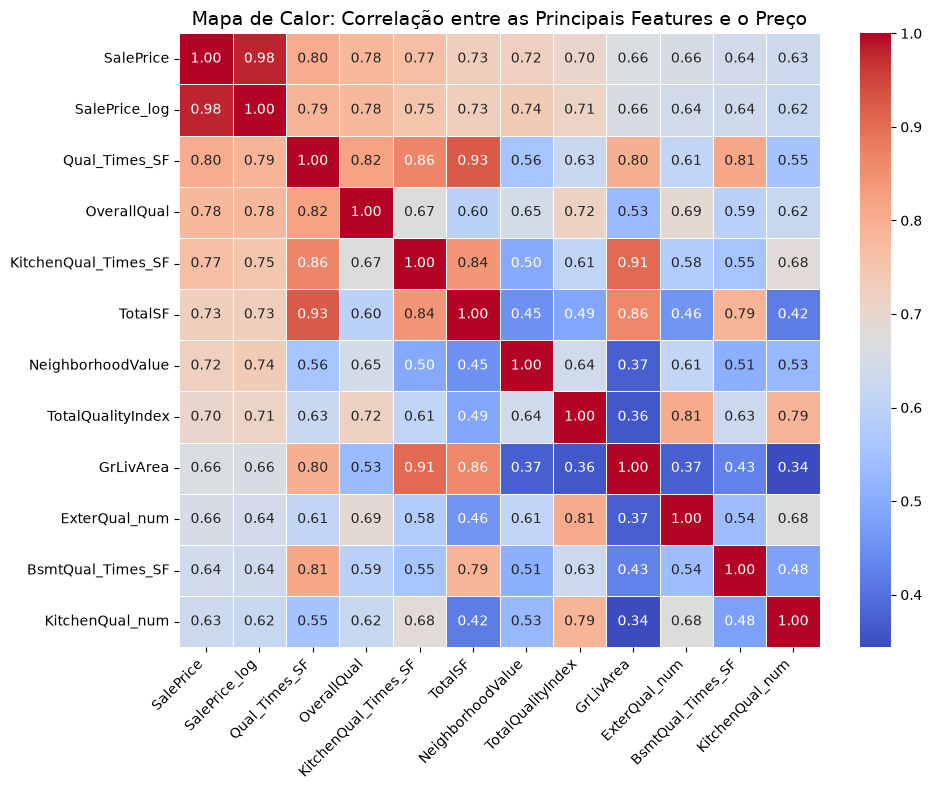

In [5]:
# 1. Selecionar as 12 variáveis numéricas mais correlacionadas com o SalePrice
k = 12 
correlation_matrix = train_features.corr(numeric_only=True)
top_cols = correlation_matrix.nlargest(k, 'SalePrice')['SalePrice'].index

# 2. Calcular a matriz de correlação apenas para este subconjunto de topo
top_corr_matrix = train_features[top_cols].corr()

# 3. Plotar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Mapa de Calor: Correlação entre as Principais Features e o Preço', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Tratando os Valores Faltantes para Evitar Erro no Modelo

In [6]:
# 1. Calcular a quantidade e a percentagem de valores em falta em X_train
missing_data = pd.DataFrame({
    'Total_Missing': X_train.isnull().sum(),
    'Percentual_%': round((X_train.isnull().sum() / len(X_train)) * 100,2)
})

# 2. Filtrar apenas as colunas que têm valores em falta e ordenar do maior para o menor
missing_data = missing_data[missing_data['Total_Missing'] > 0].sort_values(by='Percentual_%', ascending=False)

print(f"Total de colunas com valores em falta: {len(missing_data)}")
display(missing_data.head(15))

Total de colunas com valores em falta: 12


,Total_Missing,Percentual_%
GarageYrBlt,60,5.41
GarageFinish,60,5.41
GarageQual,60,5.41
GarageType,60,5.41
GarageCond,60,5.41
BsmtFinType2,26,2.34
BsmtExposure,26,2.34
BsmtQual,25,2.25
BsmtFinType1,25,2.25
BsmtCond,25,2.25


In [7]:
# 1. Tratando colunas categóricas ligadas a Garagem e Cave (Nulos significam ausência do elemento)
cols_garage_cat = ['GarageFinish', 'GarageQual', 'GarageType', 'GarageCond']
cols_bsmt_cat = ['BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType2', 'BsmtFinType1']

for col in cols_garage_cat + cols_bsmt_cat:
    X_train[col] = X_train[col].fillna('None')
    X_val[col] = X_val[col].fillna('None')

# 2. Tratando colunas numéricas de Garagem e Alvenaria
X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(0)
X_val['GarageYrBlt'] = X_val['GarageYrBlt'].fillna(0)

X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(0)
X_val['MasVnrArea'] = X_val['MasVnrArea'].fillna(0)

# 3. Tratando o único valor em falta em 'Electrical' usando a moda do treino
electrical_mode = X_train['Electrical'].mode()[0]
X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)
X_val['Electrical'] = X_val['Electrical'].fillna(electrical_mode)

# Verificação final de nulos em X_train
print("Valores em falta restantes em X_train:", X_train.isnull().sum().sum())

Valores em falta restantes em X_train: 0


## Codificação Das Variáveis Categóricas

In [8]:
# 1. Aplicando One-Hot Encoding nas variáveis categóricas
X_train_encoded = pd.get_dummies(X_train)
X_val_encoded = pd.get_dummies(X_val)

# 2. Garantir que o treino e a validação têm exatamente as mesmas colunas (importante após o get_dummies)
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)

print(f"Colunas após codificação (X_train): {X_train_encoded.shape[1]}")

Colunas após codificação (X_train): 268


In [9]:
import re

# 1. Limpar os nomes das colunas de treino e validação exatamente com a mesma regra
def clean_feature_names(df):
    df = df.copy()
    df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
    return df

X_train_encoded = clean_feature_names(X_train_encoded)
X_val_encoded = clean_feature_names(X_val_encoded)

# 2. Realignar para garantir que ambas têm exatamente as mesmas colunas na mesma ordem
X_train_encoded, X_val_encoded = X_train_encoded.align(
    X_val_encoded, join='left', axis=1, fill_value=0
)

print("Colunas limpas e alinhadas com sucesso!")

Colunas limpas e alinhadas com sucesso!


## Treinando o Primeiro Modelo XGBoost

In [10]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# 1. Instanciar o XGBoost com parâmetros avançados de regularização e estocasticidade
model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.0211,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

# 2. Treinar o modelo otimizado
model.fit(
    X_train_encoded, y_train,
    eval_set=[(X_val_encoded, y_val)],
    verbose=100
)

# 3. Avaliar o modelo
preds_xgb = model.predict(X_val_encoded)
rmse_xgb = np.sqrt(mean_squared_error(y_val, preds_xgb))

print(f"\n Novo RMSE (RMSLE) do XGBoost Ajustado: {rmse_xgb:.5f}")
print(f" Melhor árvore (iteração): {model.best_iteration}")

[0]	validation_0-rmse:0.33563
[100]	validation_0-rmse:0.14738
[200]	validation_0-rmse:0.11877
[300]	validation_0-rmse:0.10975
[400]	validation_0-rmse:0.10513
[500]	validation_0-rmse:0.10252
[600]	validation_0-rmse:0.10083
[700]	validation_0-rmse:0.09957
[800]	validation_0-rmse:0.09875
[900]	validation_0-rmse:0.09826
[1000]	validation_0-rmse:0.09769
[1100]	validation_0-rmse:0.09722
[1200]	validation_0-rmse:0.09678
[1300]	validation_0-rmse:0.09648
[1400]	validation_0-rmse:0.09615
[1500]	validation_0-rmse:0.09588
[1600]	validation_0-rmse:0.09574
[1700]	validation_0-rmse:0.09558
[1800]	validation_0-rmse:0.09542
[1900]	validation_0-rmse:0.09537
[2000]	validation_0-rmse:0.09523
[2100]	validation_0-rmse:0.09515
[2200]	validation_0-rmse:0.09499
[2300]	validation_0-rmse:0.09491
[2400]	validation_0-rmse:0.09487
[2500]	validation_0-rmse:0.09479
[2600]	validation_0-rmse:0.09479
[2700]	validation_0-rmse:0.09480
[2709]	validation_0-rmse:0.09479

 Novo RMSE (RMSLE) do XGBoost Ajustado: 0.09476
 Melho

## Treinando o Segundo Modelo CatBoost

In [11]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Instanciar e treinar o CatBoost
cat_model = CatBoostRegressor(
    iterations=6000,
    learning_rate=0.02,
    depth=4,                        
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train_encoded, y_train,
    eval_set=(X_val_encoded, y_val),
    early_stopping_rounds=100,
    use_best_model=True
)

# 3. Avaliar o modelo
preds_cat = cat_model.predict(X_val_encoded)
rmse_cat = np.sqrt(mean_squared_error(y_val, preds_cat))

print(f"\n Novo RMSE (RMSLE) do XGBoost Ajustado: {rmse_cat:.5f}")

0:	learn: 0.3295769	test: 0.3363719	best: 0.3363719 (0)	total: 46.4ms	remaining: 4m 38s
200:	learn: 0.1158944	test: 0.1263677	best: 0.1263677 (200)	total: 148ms	remaining: 4.28s
400:	learn: 0.0928591	test: 0.1085044	best: 0.1085044 (400)	total: 248ms	remaining: 3.46s
600:	learn: 0.0819774	test: 0.1025576	best: 0.1025576 (600)	total: 347ms	remaining: 3.12s
800:	learn: 0.0751774	test: 0.0999622	best: 0.0999622 (800)	total: 446ms	remaining: 2.89s
1000:	learn: 0.0694561	test: 0.0979528	best: 0.0979528 (1000)	total: 544ms	remaining: 2.72s
1200:	learn: 0.0642664	test: 0.0966845	best: 0.0966845 (1200)	total: 643ms	remaining: 2.57s
1400:	learn: 0.0597392	test: 0.0954010	best: 0.0954010 (1400)	total: 742ms	remaining: 2.44s
1600:	learn: 0.0563159	test: 0.0946459	best: 0.0946413 (1596)	total: 841ms	remaining: 2.31s
1800:	learn: 0.0531763	test: 0.0942057	best: 0.0942032 (1798)	total: 939ms	remaining: 2.19s
2000:	learn: 0.0502205	test: 0.0938185	best: 0.0938024 (1989)	total: 1.04s	remaining: 2.08s


## Treinando o Terceiro Modelo Elastic

In [12]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

# 1. Escalonar os dados (essencial para modelos lineares)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

# 2. Instanciar e treinar o ElasticNet
# O l1_ratio mistura Lasso (1.0) e Ridge (0.0). 0.5 é um bom equilíbrio.
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000)
elastic_model.fit(X_train_scaled, y_train)

# 3. Prever na validação
preds_elastic = elastic_model.predict(X_val_scaled)
rmse_elastic = np.sqrt(mean_squared_error(y_val, preds_elastic))
print(f"RMSE do ElasticNet isolado: {rmse_elastic:.5f}")

RMSE do ElasticNet isolado: 0.10169


## Criar o Ensemble e Testar a Validação

In [13]:
from scipy.optimize import minimize

print(f"--- PERFORMANCE ISOLADA ---")
print(f"XGBoost RMSE:    {rmse_xgb:.5f}")
print(f"CatBoost RMSE:   {rmse_cat:.5f}")
print(f"ElasticNet RMSE: {rmse_elastic:.5f}\n")

# 4. Otimizar os pesos para o Ensemble Triplo
def objective(weights):
    w1, w2, w3 = weights
    blend = w1 * preds_xgb + w2 * preds_cat + w3 * preds_elastic
    return np.sqrt(mean_squared_error(y_val, blend))

init_weights = [0.4, 0.4, 0.2]
bounds = [(0, 1), (0, 1), (0, 1)]
constraint = {'type': 'eq', 'fun': lambda w: 1 - sum(w)}

result = minimize(objective, init_weights, method='SLSQP', bounds=bounds, constraints=constraint)
w_xgb, w_cat, w_elastic = result.x
melhor_rmse_triplo = result.fun

print(f"--- ENSEMBLE TRIPLO OTIMIZADO ---")
print(f"Peso XGBoost:     {w_xgb:.4f}")
print(f"Peso CatBoost:    {w_cat:.4f}")
print(f"Peso ElasticNet:  {w_elastic:.4f}")
print(f"Novo RMSE Triplo: {melhor_rmse_triplo:.5f}")

--- PERFORMANCE ISOLADA ---
XGBoost RMSE:    0.09476
CatBoost RMSE:   0.09207
ElasticNet RMSE: 0.10169

--- ENSEMBLE TRIPLO OTIMIZADO ---
Peso XGBoost:     0.2706
Peso CatBoost:    0.5886
Peso ElasticNet:  0.1409
Novo RMSE Triplo: 0.09112


## Analisando com o SHAP

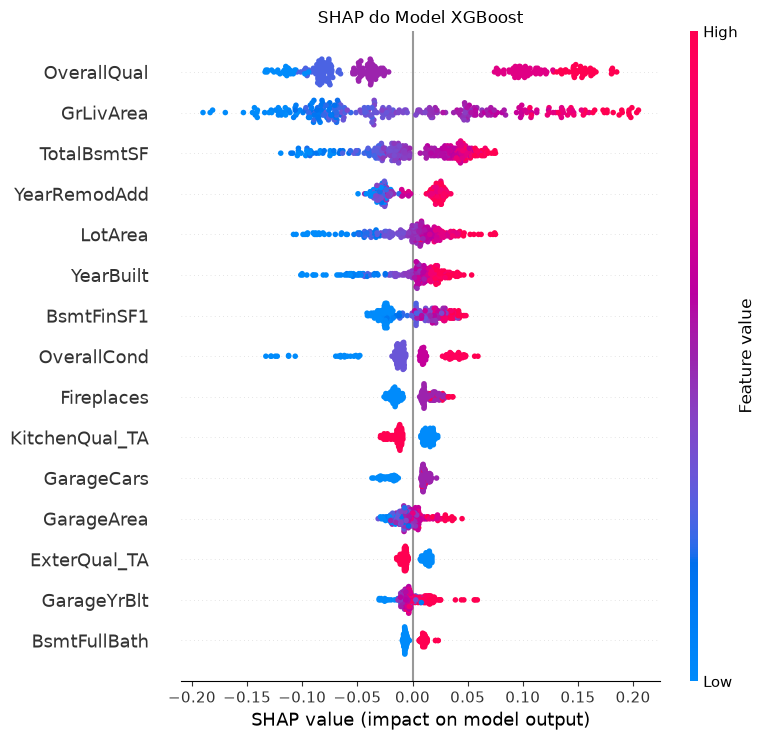

In [14]:
import shap

# 1. Calcular os valores SHAP para o CatBoost (usando o conjunto de validação)
# O TreeExplainer do SHAP é nativo e extremamente rápido para árvores
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_encoded)

# 2. Gráfico de Resumo (Summary Plot - Beeswarm)
# Mostra o top de features e se valores altos/baixos aumentam ou diminuem o preço
plt.figure(figsize=(12, 8))
plt.title('SHAP do Model XGBoost')
shap.summary_plot(shap_values, X_val_encoded, max_display=15)

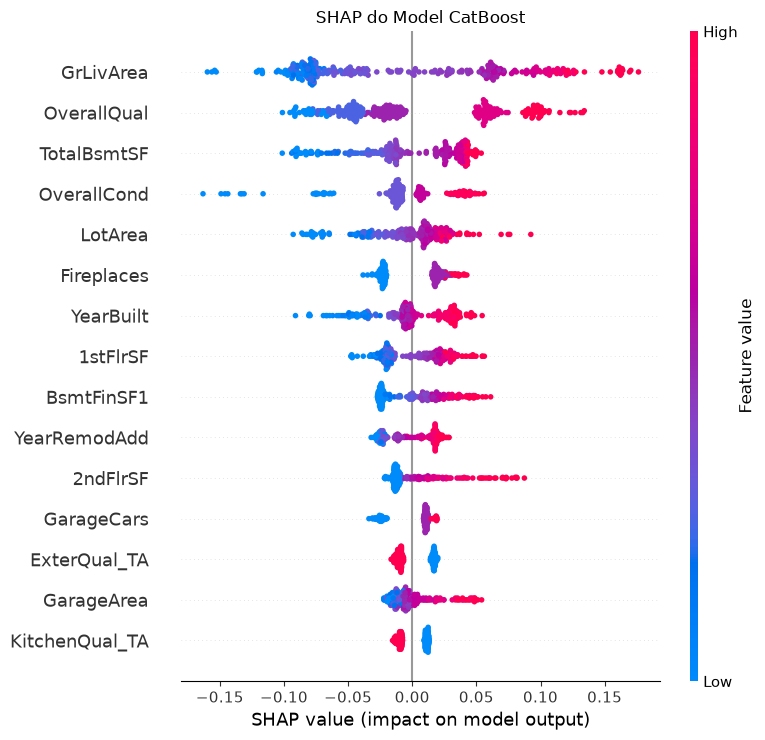

In [15]:
# 1. Calcular os valores SHAP para o CatBoost (usando o conjunto de validação)
# O TreeExplainer do SHAP é nativo e extremamente rápido para árvores
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer(X_val_encoded)

# 2. Gráfico de Resumo (Summary Plot - Beeswarm)
# Mostra o top de features e se valores altos/baixos aumentam ou diminuem o preço
plt.figure(figsize=(12, 8))
plt.title('SHAP do Model CatBoost')
shap.summary_plot(shap_values, X_val_encoded, max_display=15)

## Gerar a Submissão no Kaggle

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet

# 1. Guardar os IDs das casas para o ficheiro final
test_ids = test_df['Id']

# 2. Aplicar a mesma Função de Engenharia de Recursos (Feature Engineering)
X_test = add_all_features(test_df)

# 3. Tratamento de Valores Nulos na base de Teste
for col in cols_garage_cat + cols_bsmt_cat:
    X_test[col] = X_test[col].fillna('None')

X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(0)
X_test['MasVnrArea'] = X_test['MasVnrArea'].fillna(0)
X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)

# 4. One-Hot Encoding no Teste
X_test_encoded = pd.get_dummies(X_test)

# 5. Alinhar as colunas do Teste com as colunas exatas do Treino
_, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Limpar os nomes das colunas de teste com a mesma regra regex
X_test_encoded.columns = X_test_encoded.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

# ➔ GARANTIR QUE NÃO SOBRAM NANS (Preencher com 0 antes do scaler)
X_test_encoded = X_test_encoded.fillna(0)

# 6. Escalonamento obrigatório para o ElasticNet
X_test_scaled = scaler.transform(X_test_encoded)

# ==========================================================
# 7. Instanciar, treinar o ElasticNet e prever
# ==========================================================
elastic_optimized = ElasticNet(
    alpha=0.01,          # Mantém o teu valor definido
    l1_ratio=0.5,        # Mantém o teu valor definido
    max_iter=50000,
    random_state=42
)
elastic_optimized.fit(X_train_scaled, y_train)

# Gerar previsões de teste com os TRÊS modelos
preds_xgb_test = model.predict(X_test_encoded)
preds_cat_test = cat_model.predict(X_test_encoded)
preds_elastic_test = elastic_optimized.predict(X_test_scaled)

# 8. Aplicar a ponderação ótima do Ensemble Triplo
preds_ensemble_log = (w_xgb * preds_xgb_test) + (w_cat * preds_cat_test) + (w_elastic * preds_elastic_test)

# 9. Reverter a transformação log1p para voltar ao valor real em dólares
final_preds = np.expm1(preds_ensemble_log)

# 10. Criar o DataFrame de Submissão e exportar
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})

submission.to_csv('submission_triple_ensemble.csv', index=False)

print("Ficheiro 'submission_triple_ensemble.csv' gerado com sucesso!")
display(submission.head())

Ficheiro 'submission_triple_ensemble.csv' gerado com sucesso!


,Id,SalePrice
0,1461,124129.043166
1,1462,156331.904631
2,1463,185261.167499
3,1464,196815.570373
4,1465,181445.913277


## Submission

Ensemble de XGBoost + CastBoost usando Isolation Forest + Log1p para tratar os Outliers: 0.14576